# GraphPCA on a cycle graph with a uniform probability measure

Every GraphPCA notebook in this project calls the implementation `graphpca_core_annotated.py`.

This notebook does four things:

1. constructs one cycle graph whose radius is $1$;
2. defines the uniform probability measure $\mu$;
3. computes GraphPCA once at a fixed diffusion time using `fit_graphpca`;
4. plots this graph colored by $\mu$ and by PC1--PC4, followed by
   its eigenvalues and explained variance.

`basis[:, j]` is PC $j$ in edge space, while
`coordinates[y, j]` is the value assigned by PC $j$ to vertex $y$.

The example sets every edge length to $\pi / 100$.
Since the formulas retain
$C=\operatorname{diag}(\ell)$ explicitly.

`EDGE_LENGTH` may be changed to another positive value when needed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

# graphpca_core_annotated.py is required for this notebook.
import graphpca_core_annotated as gpca

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

# Experiment settings
N_VERTICES = 200
EDGE_LENGTH = np.pi / 100
AFFINITY_SIGMA = 1
DIFFUSION_TIME = 250

N_COMPONENTS = 12
TOP_K_EIGENVALUES = 12

## 1. Construct the cycle graph

For oriented incidence matrix $B$ and positive edge lengths $\ell$,

$$
K=B\operatorname{diag}(1/\ell), \qquad
L=B\operatorname{diag}(w)B^\top,
$$

where $w_e=\exp[-\ell_e^2/(2\sigma^2)]$ is edge affinity.

`prepare_graph` inside `fit_graphpca` builds $B$, $\ell$, $w$, $K$ and $L$
from the graph below. We give it the node and edge orderings explicitly.

In [2]:
# Edges (0,1), ..., (n-2,n-1), (n-1,0)
start = np.arange(N_VERTICES)
end = (start + 1) % N_VERTICES
edges = np.column_stack((start, end))
n_edges = len(edges)

# The edge LENGTH goes in the 'weight' attribute.
# graphpca_core turns lengths into affinities itself.
cycle_graph = nx.Graph()
cycle_graph.add_nodes_from(range(N_VERTICES))

for u, v in edges:
    cycle_graph.add_edge(
        int(u),
        int(v),
        weight=EDGE_LENGTH,
    )

# Fix the orderings, so every array below is indexed the same way.
NODE_LIST = list(range(N_VERTICES))
EDGE_LIST = [(int(u), int(v)) for u, v in edges]

# Coordinates used only to draw the original cycle.
theta = 2.0 * np.pi * np.arange(N_VERTICES) / N_VERTICES
xy = np.column_stack((np.cos(theta), np.sin(theta)))

print(f"Cycle graph: {N_VERTICES} vertices, {n_edges} edges")

Cycle graph: 200 vertices, 200 edges


## 2. Define and plot the uniform measure

Every vertex receives the same probability mass:

$$
\mu(y)=\frac{1}{n}, \qquad y=0,\ldots,n-1.
$$

The right panel draws the original cycle and uses vertex color
to represent $\mu(y)$.

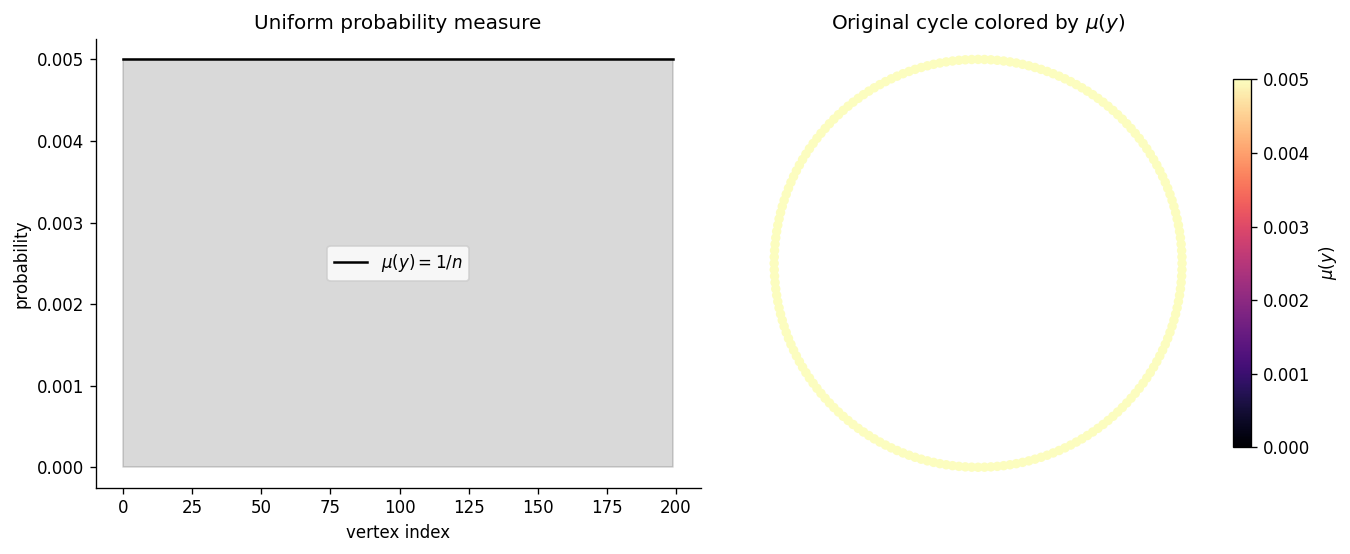

sum(mu) = 1.000000000000


In [3]:
vertices = np.arange(N_VERTICES)
mu = np.full(N_VERTICES, 1.0 / N_VERTICES)

def draw_cycle(ax, values, cmap, vmin, vmax):
    for u, v in edges:
        ax.plot(
            xy[[u, v], 0],
            xy[[u, v], 1],
            color="0.78",
            linewidth=0.8,
            zorder=1,
        )
    points = ax.scatter(
        xy[:, 0],
        xy[:, 1],
        c=values,
        s=32,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolors="none",
        zorder=2,
    )
    ax.set_aspect("equal")
    ax.axis("off")
    return points


fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.7))
axes[0].fill_between(vertices, mu, color="black", alpha=0.15)
axes[0].plot(vertices, mu, color="black", label=r"$\mu(y)=1/n$")
axes[0].set_xlabel("vertex index")
axes[0].set_ylabel("probability")
axes[0].set_title("Uniform probability measure")
axes[0].legend()

points = draw_cycle(
    axes[1], mu, cmap="magma", vmin=0.0, vmax=mu.max()
)
axes[1].set_title(r"Original cycle colored by $\mu(y)$")
fig.colorbar(points, ax=axes[1], label=r"$\mu(y)$", shrink=0.82)
fig.tight_layout()
plt.show()

print(f"sum(mu) = {mu.sum():.12f}")

## 3. Compute GraphPCA with `fit_graphpca`

At diffusion time $t$,

$$
H_t=\exp(-tL), \qquad G_t=K^\top H_t.
$$

Center the columns of $G_t$ using $\mu$ and form

$$
U=C^{1/2}P_w, \qquad C=\operatorname{diag}(\ell).
$$

If $U=Q\operatorname{diag}(s)R^\top$, then
$\lambda_j=s_j^2$ and $v_j=C^{-1/2}Q_j$.

`fit_graphpca` does all of that.

- `sigma=AFFINITY_SIGMA` &mdash; without it `prepare_graph` defaults $\sigma$ to
  the **median edge length** ($\pi/100$ here), which changes $\lambda_1$ by a
  factor of 1.6.
- `solver="exact"` &mdash; one SVD of $U$, never a squared matrix.


Sections 6 and 7 refit at other times to show how the harmonics move.

In [4]:
fit = gpca.fit_graphpca(
    cycle_graph,
    potential_function="heat_kernel",
    t_values=(DIFFUSION_TIME,),
    mu=mu,
    k_keep=N_COMPONENTS,
    sigma=AFFINITY_SIGMA,
    solver="exact",
    pin_signs=True,
    node_list=NODE_LIST,
    edge_list=EDGE_LIST,
)

result = fit.by_t[float(DIFFUSION_TIME)]

# The same names the rest of the notebook already uses.
K = fit.K
ell = fit.ell
L = fit.L
laplacian_values = fit.evals_L
laplacian_vectors = fit.evecs_L

heat = fit.potential_dict[float(DIFFUSION_TIME)]

eigenvalues = result.eigenvalues
basis = result.basis
coordinates = result.scores
total_variance = result.total_variance
explained_variance = result.explained_variance_ratio

k = result.n_components

print(f"sigma used: {fit.sigma:g}")
print(f"components returned: {k} of {N_COMPONENTS} requested")
print(f"rank capacity: {result.rank_capacity}")
print(fit.connectivity)

sigma used: 1
components returned: 12 of 12 requested
rank capacity: 199
affinity connectivity: CONNECTED   lambda2/lambda_max = 2.467e-04   zero modes = 1   floor edges = 0


In [5]:
# The three identities a correct fit must satisfy.
# check_graphpca raises if any of them fails.
identities = gpca.check_graphpca(result, verbose=True)

metric_gram = basis.T @ (ell[:, None] * basis)
coordinate_variances = np.sum(mu[:, None] * coordinates**2, axis=0)
print(
    "C-orthogonality error:",
    np.max(np.abs(metric_gram - np.eye(k))),
)
print(
    "coordinate-variance error:",
    np.max(np.abs(coordinate_variances - eigenvalues)),
)

  c_orthonormality_error     1.776e-15   relative 1.776e-15
  score_mean_error           7.827e-19   relative 5.651e-17
  score_covariance_error     8.530e-19   relative 8.893e-15
  all three identities hold at t=250.0
C-orthogonality error: 1.7763568394002505e-15
coordinate-variance error: 1.4907779871675686e-19


In [6]:
def oriented_edges_from_K(K, tol=1e-12):
    """Return (tail, head, edge_index) using -1 -> +1 orientation."""
    K_array = K.toarray() if hasattr(K, "toarray") else np.asarray(K)

    directed_edges = []
    for e in range(K_array.shape[1]):
        tail = np.flatnonzero(K_array[:, e] < -tol)
        head = np.flatnonzero(K_array[:, e] > tol)

        if len(tail) != 1 or len(head) != 1:
            raise ValueError(
                f"Column {e} is not an oriented edge-incidence column: "
                f"negative rows={tail}, positive rows={head}"
            )

        directed_edges.append((tail[0], head[0], e))

    return directed_edges


def draw_oriented_cycle_from_K(ax, K, values, cmap, vmin, vmax):
    directed_edges = oriented_edges_from_K(K)

    for tail, head, e in directed_edges:
        ax.annotate(
            "",
            xy=xy[head],
            xytext=xy[tail],
            arrowprops=dict(
                arrowstyle="-|>",
                color="0.60",
                linewidth=1.0,
                mutation_scale=10,
                shrinkA=7,
                shrinkB=7,
            ),
            zorder=1,
        )

    points = ax.scatter(
        xy[:, 0],
        xy[:, 1],
        c=values,
        s=8,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolors="none",
        zorder=2,
    )

    ax.set_aspect("equal")
    ax.axis("off")
    return points

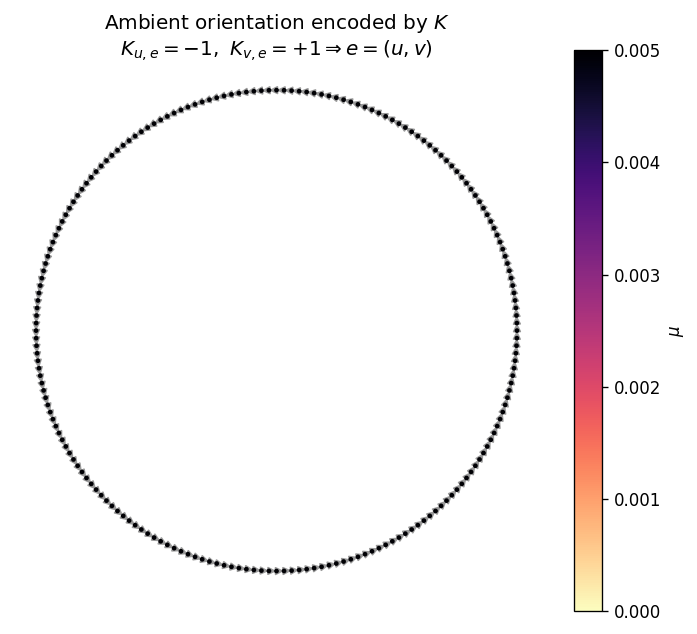

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))

points = draw_oriented_cycle_from_K(
    ax,
    K,
    mu,
    cmap="magma_r",
    vmin=0.0,
    vmax=mu.max(),
)

ax.set_title(
    r"Ambient orientation encoded by $K$"
    "\n"
    r"$K_{u,e}=-1,\ K_{v,e}=+1 \Rightarrow e=(u,v)$"
)

fig.colorbar(points, ax=ax, label=r"$\mu$", shrink=0.82)
fig.tight_layout()
plt.show()

In [8]:
indegree = np.asarray((K > 0).sum(axis=1)).ravel()
outdegree = np.asarray((K < 0).sum(axis=1)).ravel()

assert np.all(indegree == 1)
assert np.all(outdegree == 1)

print("Verified: every vertex has indegree 1 and outdegree 1.")

Verified: every vertex has indegree 1 and outdegree 1.


## 4. Original cycle colored by PC1--PC4

Color at vertex $y$ is `coordinates[y, j]`. The four PC panels share one
symmetric color scale, $\pm\max_{y,\,j\le4}|\text{PC}_j(y)|$, and one colorbar.

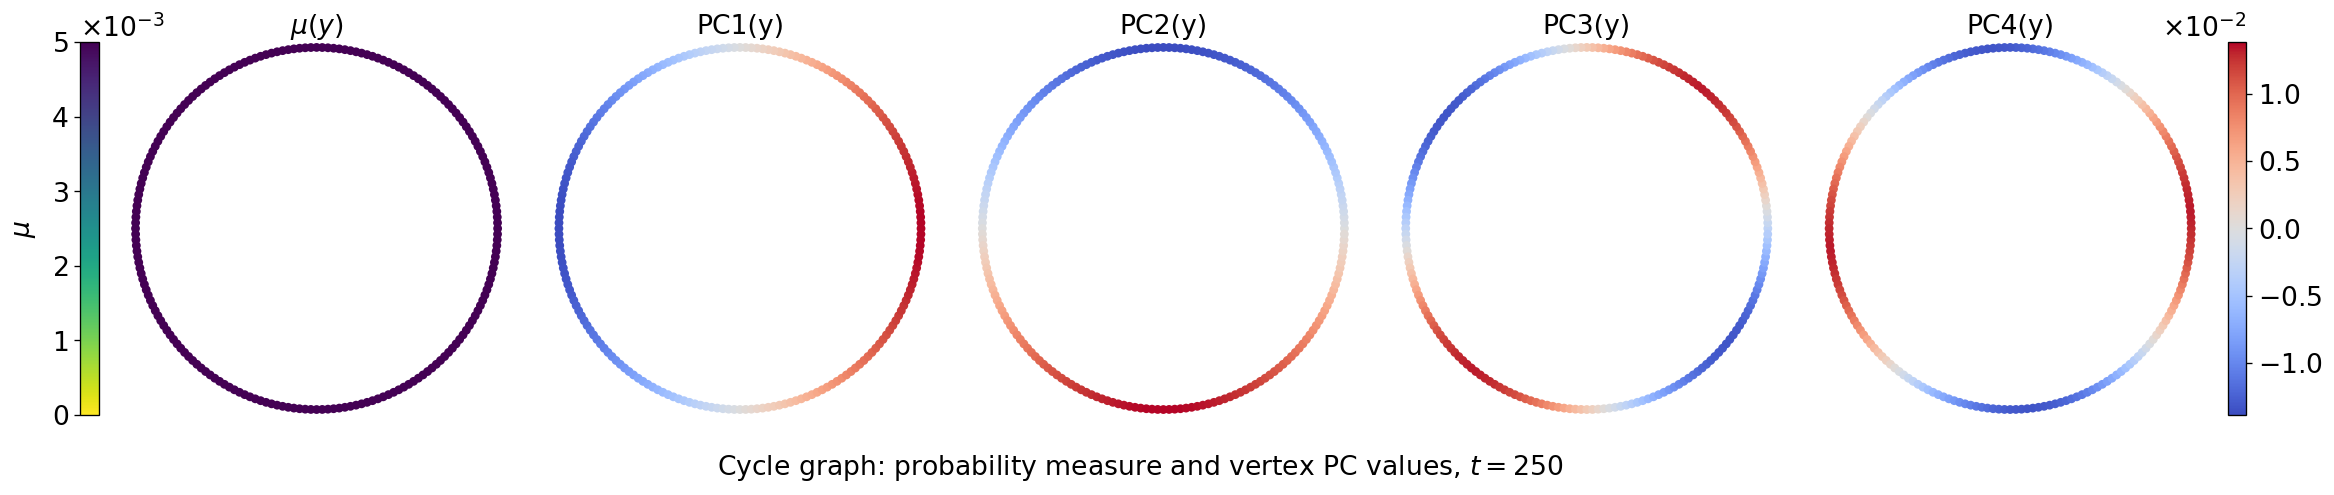

Saved cycle_graph_mu_pc1_pc4_t=250.png
Saved cycle_graph_mu_pc1_pc4_t=250.pdf


In [9]:
# Publication plot:
# left mu colorbar | mu | PC1 | PC2 | PC3 | PC4 | PC colorbar

from matplotlib.ticker import ScalarFormatter
def scientific_colorbar_formatter():
    formatter = ScalarFormatter(
        useMathText=True,
    )
    formatter.set_scientific(True)

    # Force scientific notation at every magnitude.
    formatter.set_powerlimits((0, 0))

    return formatter

PLOT_FONT_SIZE = 16
OUTPUT_NAME = f"cycle_graph_mu_pc1_pc4_t={DIFFUSION_TIME:g}"

plt.rcParams.update({
    "font.size": PLOT_FONT_SIZE,
    "axes.titlesize": PLOT_FONT_SIZE,
    "axes.labelsize": PLOT_FONT_SIZE,
    "xtick.labelsize": PLOT_FONT_SIZE,
    "ytick.labelsize": PLOT_FONT_SIZE,
})


def draw_cycle_for_publication(
    ax,
    values,
    cmap,
    vmin,
    vmax,
):
    """Draw the cycle without x- or y-axes."""

    # Draw edges.
    for u, v in edges:
        ax.plot(
            xy[[u, v], 0],
            xy[[u, v], 1],
            color="0.80",
            linewidth=0.7,
            zorder=1,
        )

    # Draw vertices.
    points = ax.scatter(
        xy[:, 0],
        xy[:, 1],
        c=values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        s=28,
        edgecolors="none",
        zorder=2,
    )

    ax.set_aspect("equal")
    ax.set_xlim(-1.03, 1.03)
    ax.set_ylim(-1.03, 1.03)
    ax.margins(0)
    ax.axis("off")

    return points


# Figure layout
# mu colorbar | mu | PC1 | PC2 | PC3 | PC4 | PC colorbar
fig = plt.figure(figsize=(19, 4.2))

grid = fig.add_gridspec(
    nrows=1,
    ncols=7,
    width_ratios=[
        0.045,  # mu colorbar
        1.0,    # graph colored by mu
        1.0,    # PC1
        1.0,    # PC2
        1.0,    # PC3
        1.0,    # PC4
        0.045,  # shared PC colorbar
    ],
    wspace=0.04,
)



mu_colorbar_ax = fig.add_subplot(grid[0, 0])
mu_ax = fig.add_subplot(grid[0, 1])

pc_axes = [
    fig.add_subplot(grid[0, column])
    for column in range(2, 6)
]

pc_colorbar_ax = fig.add_subplot(grid[0, 6])


# Original cycle colored by mu
mu_points = draw_cycle_for_publication(
    mu_ax,
    mu,
    cmap="viridis_r",
    vmin=0.0,
    vmax=float(mu.max()),
)

mu_ax.set_title(
    r"$\mu(y)$",
    fontsize=PLOT_FONT_SIZE,
    pad=5,
)

mu_colorbar = fig.colorbar(
    mu_points,
    cax=mu_colorbar_ax,
    orientation="vertical",
    format=scientific_colorbar_formatter(),
)

mu_colorbar.update_ticks()

mu_colorbar.ax.yaxis.set_ticks_position("left")
mu_colorbar.ax.yaxis.set_label_position("left")

mu_colorbar.set_label(
    r"$\mu(y)$",
    fontsize=PLOT_FONT_SIZE,
    labelpad=8,
)

mu_colorbar.ax.tick_params(
    labelsize=PLOT_FONT_SIZE,
)

# Format and resize the multiplier, such as ×10^{-3}.
mu_colorbar.ax.yaxis.get_offset_text().set_fontsize(
    PLOT_FONT_SIZE
)

# Put mu ticks and label on the left.
mu_colorbar.ax.yaxis.set_ticks_position("left")
mu_colorbar.ax.yaxis.set_label_position("left")

mu_colorbar.set_label(
    r"$\mu$",
    fontsize=PLOT_FONT_SIZE,
    labelpad=8,
)

mu_colorbar.ax.tick_params(
    labelsize=PLOT_FONT_SIZE,
)


# Original cycle colored by PC1–PC4
# Use one common symmetric scale for all four PCs.
pc_bound = max(
    float(np.max(np.abs(coordinates[:, :4]))),
    1e-15,
)

pc_points = None

for j, ax in enumerate(pc_axes):
    pc_points = draw_cycle_for_publication(
        ax,
        coordinates[:, j],
        cmap="coolwarm",
        vmin=-pc_bound,
        vmax=pc_bound,
    )

    ax.set_title(
        #rf"PC{j + 1}: $\alpha_{j + 1}(y)$",
        rf"PC{j + 1}(y)",
        fontsize=PLOT_FONT_SIZE,
        pad=5,
    )


# Shared PC colorbar on the right.
pc_colorbar = fig.colorbar(
    pc_points,
    cax=pc_colorbar_ax,
    orientation="vertical",
    format=scientific_colorbar_formatter(),
)

pc_colorbar.update_ticks()

pc_colorbar.ax.tick_params(
    labelsize=PLOT_FONT_SIZE,
)

pc_colorbar.ax.yaxis.get_offset_text().set_fontsize(
    PLOT_FONT_SIZE
)

#pc_colorbar.set_label(
    #r"Vertex PC coordinate $PCj(y)$",
    #fontsize=PLOT_FONT_SIZE,
    #labelpad=8,
#)

pc_colorbar.ax.tick_params(
    labelsize=PLOT_FONT_SIZE,
)


# Overall subtitle at the bottom
fig.text(
    0.5,
    0.025,
    rf"Cycle graph: probability measure and vertex PC values, "
    rf"$t={DIFFUSION_TIME:g}$",
    ha="center",
    va="bottom",
    fontsize=PLOT_FONT_SIZE,
)
fig.subplots_adjust(
    left=0.035,
    right=0.985,
    top=0.90,
    bottom=0.16,
)



# Save PNG and PDF


fig.savefig(
    f"{OUTPUT_NAME}.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    f"{OUTPUT_NAME}.pdf",
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Saved {OUTPUT_NAME}.png")
print(f"Saved {OUTPUT_NAME}.pdf")

## 5. Top eigenvalues and variance explained

$$
\text{explained variance ratio}_j
=\frac{\lambda_j}{\text{total variance}}
$$

On a cycle the eigenvalues come in **exactly degenerate pairs**, one pair per
Fourier frequency. Inside a pair the individual axes are arbitrary, so read the
pairs, not the single components.

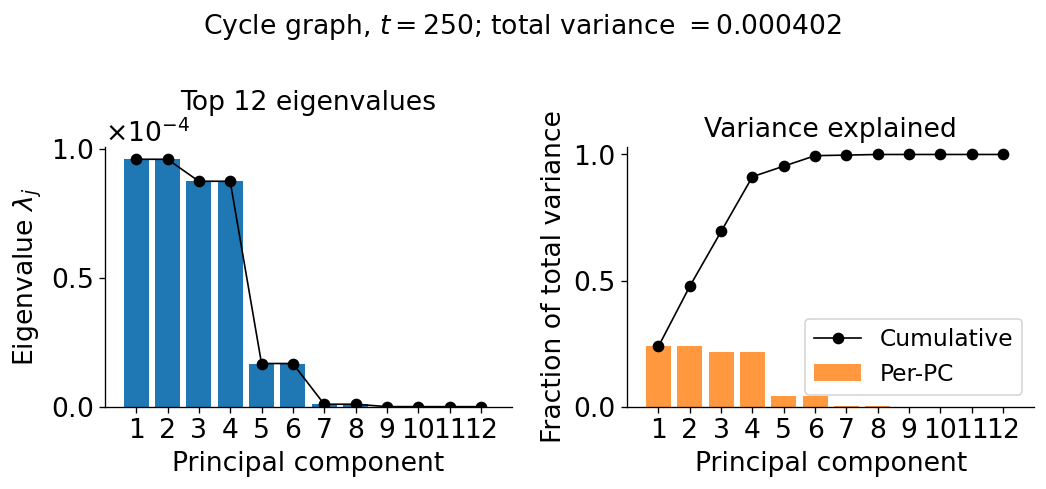

Diffusion time used: t = 250
Saved cycle_graph_eigenvalues_variance_t250.png
Saved cycle_graph_eigenvalues_variance_t250.pdf


In [10]:
# Eigenvalues and explained variance
SPECTRUM_OUTPUT_NAME = (
    f"cycle_graph_eigenvalues_variance_t{DIFFUSION_TIME:g}"
)

number_to_plot = min(
    TOP_K_EIGENVALUES,
    len(eigenvalues),
)

pc = np.arange(1, number_to_plot + 1)
shown_eigenvalues = eigenvalues[:number_to_plot]
shown_explained = explained_variance[:number_to_plot]
cumulative = np.cumsum(shown_explained)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4.2),
)


# Top eigenvalues
axes[0].bar(
    pc,
    shown_eigenvalues,
    color="tab:blue",
)

axes[0].plot(
    pc,
    shown_eigenvalues,
    color="black",
    marker="o",
    linewidth=1,
)

axes[0].set_xlabel(
    "Principal component",
    fontsize=PLOT_FONT_SIZE,
)

axes[0].set_ylabel(
    r"Eigenvalue $\lambda_j$",
    fontsize=PLOT_FONT_SIZE,
)

axes[0].set_title(
    f"Top {number_to_plot} eigenvalues",
    fontsize=PLOT_FONT_SIZE,
)

axes[0].set_xticks(pc)
axes[0].tick_params(
    axis="both",
    labelsize=PLOT_FONT_SIZE,
)
from matplotlib.ticker import ScalarFormatter

scientific_formatter = ScalarFormatter(useMathText=True)
scientific_formatter.set_scientific(True)
scientific_formatter.set_powerlimits((0, 0))

axes[0].yaxis.set_major_formatter(scientific_formatter)
axes[0].ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(0, 0),
)
axes[0].yaxis.get_offset_text().set_fontsize(PLOT_FONT_SIZE)

# Explained variance
axes[1].bar(
    pc,
    shown_explained,
    color="tab:orange",
    alpha=0.8,
    label="Per-PC",
)

axes[1].plot(
    pc,
    cumulative,
    color="black",
    marker="o",
    linewidth=1,
    label="Cumulative",
)

axes[1].set_xlabel(
    "Principal component",
    fontsize=PLOT_FONT_SIZE,
)

axes[1].set_ylabel(
    "Fraction of total variance",
    fontsize=PLOT_FONT_SIZE,
)

axes[1].set_ylim(0.0, 1.03)
axes[1].set_xticks(pc)

axes[1].set_title(
    "Variance explained",
    fontsize=PLOT_FONT_SIZE,
)

axes[1].tick_params(
    axis="both",
    labelsize=PLOT_FONT_SIZE,
)

axes[1].legend(
    fontsize=PLOT_FONT_SIZE - 2,
)


fig.suptitle(
    rf"Cycle graph, $t={DIFFUSION_TIME:g}$; "
    rf"total variance $={total_variance:.4g}$",
    fontsize=PLOT_FONT_SIZE,
)

fig.tight_layout()


# Save a high-resolution PNG.
fig.savefig(
    f"{SPECTRUM_OUTPUT_NAME}.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

# Save a vector PDF for publication.
fig.savefig(
    f"{SPECTRUM_OUTPUT_NAME}.pdf",
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Diffusion time used: t = {DIFFUSION_TIME:g}")
print(f"Saved {SPECTRUM_OUTPUT_NAME}.png")
print(f"Saved {SPECTRUM_OUTPUT_NAME}.pdf")

# Figure for paper

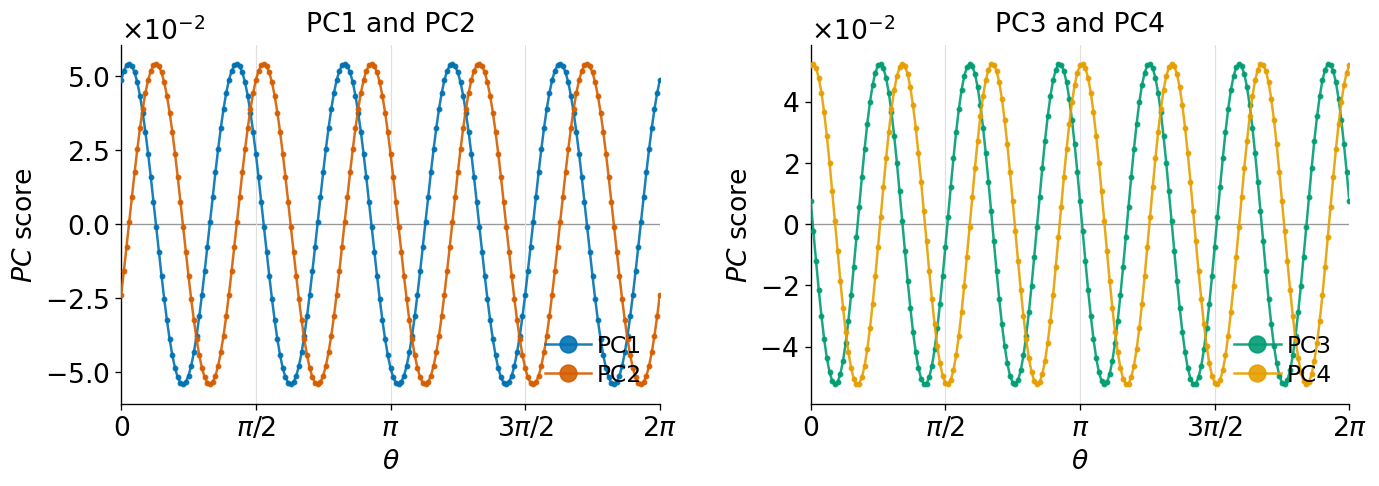

Saved cycle_graph_pc1_pc4_oscillations_t_20.png
Saved cycle_graph_pc1_pc4_oscillations_t_20.pdf


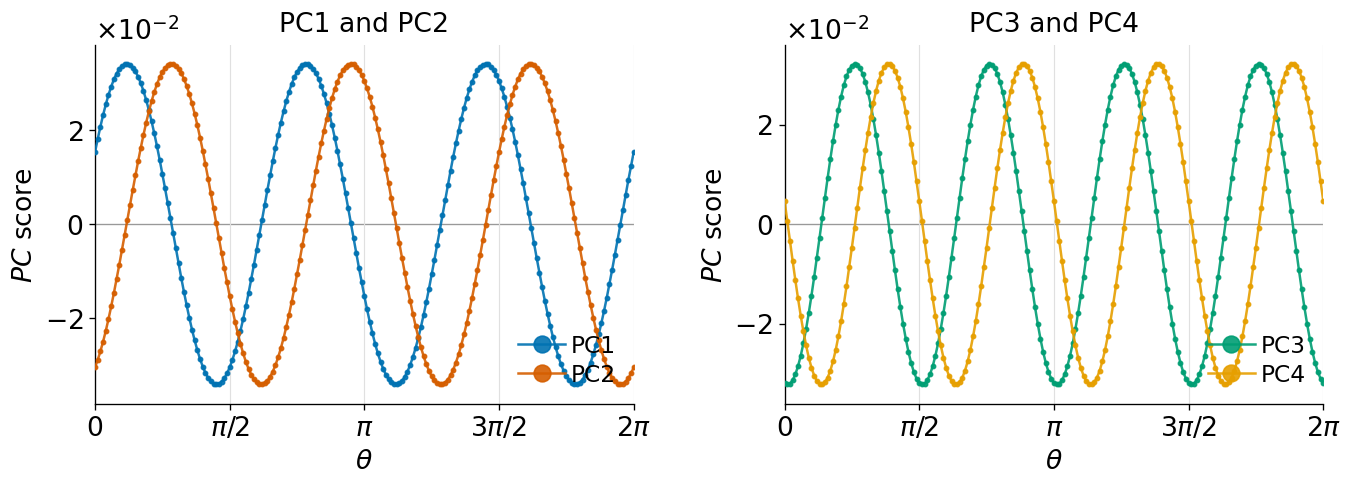

Saved cycle_graph_pc1_pc4_oscillations_t_50.png
Saved cycle_graph_pc1_pc4_oscillations_t_50.pdf


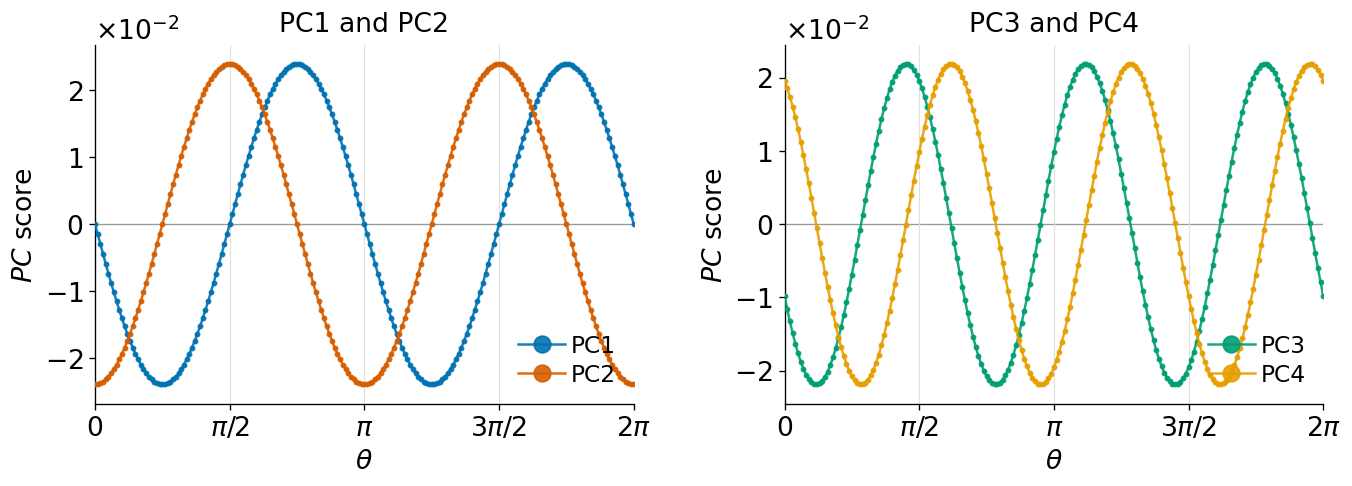

Saved cycle_graph_pc1_pc4_oscillations_t_100.png
Saved cycle_graph_pc1_pc4_oscillations_t_100.pdf


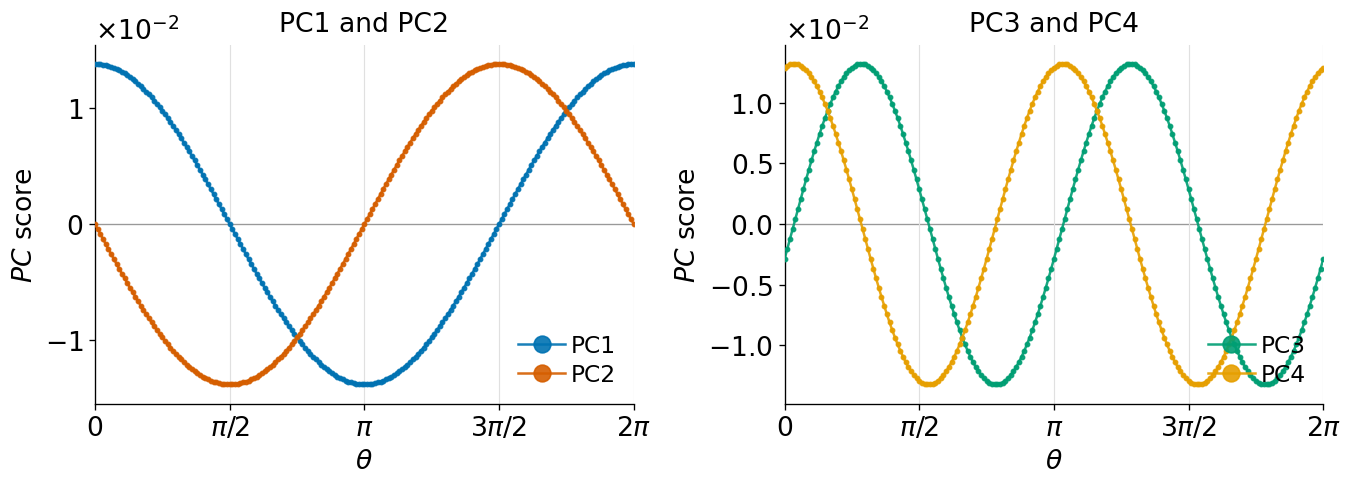

Saved cycle_graph_pc1_pc4_oscillations_t_250.png
Saved cycle_graph_pc1_pc4_oscillations_t_250.pdf


In [11]:
# PC1-PC2 and PC3-PC4 along the unwrapped cycle, at several diffusion times
FIGURE_TIMES = (20, 50, 100, 250)

# Refit at every requested time in a single call. `fit_graphpca` builds the
# graph setup and the Laplacian eigendecomposition once and then solves each t
# independently, so the t = DIFFUSION_TIME panel is bit-identical to section 3.
figure_fit = gpca.fit_graphpca(
    cycle_graph,
    potential_function="heat_kernel",
    t_values=FIGURE_TIMES,
    mu=mu,
    k_keep=N_COMPONENTS,
    sigma=AFFINITY_SIGMA,
    solver="exact",
    pin_signs=True,
    node_list=NODE_LIST,
    edge_list=EDGE_LIST,
)

def plot_pc_oscillations(scores, diffusion_time):
    """Draw and save the PC1-PC2 / PC3-PC4 figure for one diffusion time."""
    output_name = f"cycle_graph_pc1_pc4_oscillations_t_{diffusion_time:g}"

    n_vertices = scores.shape[0]
    cycle_order = np.arange(n_vertices)
    theta = 2.0 * np.pi * np.arange(n_vertices) / n_vertices

    pc12_values = np.asarray(scores[cycle_order, :2], dtype=float)
    pc34_values = np.asarray(scores[cycle_order, 2:4], dtype=float)

    # Repeat the first vertex at 2*pi
    theta_closed = np.append(theta, 2.0 * np.pi)
    pc12_values_closed = np.vstack([pc12_values, pc12_values[0]])
    pc34_values_closed = np.vstack([pc34_values, pc34_values[0]])

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11.5, 4.4))
    pc12_ax, pc34_ax = axes

    pc1_color = "#0072B2"  # blue
    pc2_color = "#D55E00"  # red
    pc3_color = "#009E73"  # dark green
    pc4_color = "#E69F00"  # orange

    panels = (
        (pc12_ax, pc12_values_closed, (pc1_color, pc2_color),
         ("PC1", "PC2"), r"PC1 and PC2"),
        (pc34_ax, pc34_values_closed, (pc3_color, pc4_color),
         ("PC3", "PC4"), r"PC3 and PC4"),
    )

    for ax, values_closed, colors, labels, title in panels:
        for column, (color, label) in enumerate(zip(colors, labels)):
            ax.plot(
                theta_closed,
                values_closed[:, column],
                color=color,
                linewidth=1.5,
                marker="o",
                markersize=2.5,
                alpha=0.90,
                label=label,
                zorder=3,
            )

        ax.axhline(0.0, color="0.60", linewidth=0.8, zorder=0)

        bound = max(float(np.max(np.abs(values_closed))), 1e-15)
        ax.set_ylim(-1.12 * bound, 1.12 * bound)

        ax.set_title(title, fontsize=PLOT_FONT_SIZE, pad=8)
        ax.set_ylabel(r"$PC$ score", fontsize=PLOT_FONT_SIZE)
        ax.legend(
            loc="lower right",
            ncol=1,
            fontsize=PLOT_FONT_SIZE - 2,
            frameon=False,
            handletextpad=0.25,
            labelspacing=0.25,
            borderaxespad=0.35,
            markerscale=4,
        )

    # Shared axis formatting
    for ax in axes:
        ax.set_xlim(0.0, 2.0 * np.pi)
        ax.set_xticks([0.0, 0.5 * np.pi, np.pi, 1.5 * np.pi, 2.0 * np.pi])
        ax.set_xticklabels(
            [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
        )
        ax.set_xlabel(r"$\theta$", fontsize=PLOT_FONT_SIZE)
        ax.ticklabel_format(
            axis="y", style="scientific", scilimits=(0, 0), useMathText=True
        )
        ax.yaxis.get_offset_text().set_fontsize(PLOT_FONT_SIZE)
        ax.grid(axis="x", color="0.88", linewidth=0.7)
        ax.tick_params(axis="both", labelsize=PLOT_FONT_SIZE)

    fig.subplots_adjust(
        left=0.09, right=0.98, top=0.88, bottom=0.20, wspace=0.28
    )

    fig.savefig(f"{output_name}.png", dpi=300, bbox_inches="tight",
                facecolor="white")
    fig.savefig(f"{output_name}.pdf", bbox_inches="tight", facecolor="white")
    plt.show()
    return output_name


# One figure per diffusion time
for diffusion_time in FIGURE_TIMES:
    scores_t = figure_fit.by_t[float(diffusion_time)].scores
    name = plot_pc_oscillations(scores_t, diffusion_time)
    print(f"Saved {name}.png")
    print(f"Saved {name}.pdf")